In [1]:
from init_env import cfg
from dataset import load_splits, load_datasets
from models import load_model_and_history, WeightedEnsemble
from evaluate import *
from plots import *

import os
import json
import logging
import numpy as np
logging.getLogger("absl").setLevel(logging.ERROR)

In [2]:
# Extract configuration settings
DATA_PATH = cfg["paths"]["data_path"]
MODEL_PATH = cfg["paths"]["model_path"]
IMG_SIZE = tuple(cfg["img_size"])
BATCH_SIZE = cfg["batch_size"]
USE_AUTOTUNE = cfg["use_autotune"]

# Load datasets
_, _, test_df = load_splits(os.path.join(DATA_PATH, "splits"))
_, _, test_ds = load_datasets(os.path.join(DATA_PATH, "splits"))

# Load models
model_configs = [("Original", "vgg16"),
                 ("Gap", "vgg16_gap"),
                 ("Weighted", "vgg16_weighted"),
                 ("Attention", "vgg16_attention"),
                 ("Sample Weighted", "vgg16_attention_sample_weight")]

training_modes = [("FE", "Feature Extract"),
                  ("FT", "Fine Tune")]

# Dictionary to store models and histories
models = {}

for name, key in model_configs:
    for abbr, long in training_modes:
        short_name = f"{name} {abbr}" # For table readability
        long_name = f"{name} ({long})"
        suffix = "_".join(long.lower().split())
        model, history = load_model_and_history(MODEL_PATH, f"{key}_{suffix}")
        models[short_name] = {"model": model,
                              "history": history,
                              "long_name": long_name}

# Check if tensorflow detects GPU
# conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1 if nothing detected
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Check Distributions in test set

In [3]:
# Count number of samples per pathology label for each ethnicity
label_counts = test_df.groupby("ethnicity")["pathology"].value_counts().unstack(fill_value=0)
label_counts

pathology,benign,malignant,normal
ethnicity,,,
chinese,168,638,0
portuguese,3,15,43
saudi,58,16,286
uk,9,8,31
us,278,237,60
vietnamese,146,146,2712


In [4]:
# Define the grouping mapping
ethnicity_group_map = {
    "chinese": "Asian",
    "vietnamese": "Asian",
    "uk": "European",
    "portuguese": "European",
    "us": "US",
    "saudi": "Middle Eastern"
}

# Apply the mapping
test_df["ethnicity_grouped"] = test_df["ethnicity"].map(ethnicity_group_map)

In [5]:
# Count number of samples per pathology label for each ethnicity group
label_counts = test_df.groupby("ethnicity_grouped")["pathology"].value_counts().unstack()
label_counts

pathology,benign,malignant,normal
ethnicity_grouped,,,
Asian,314,784,2712
European,12,23,74
Middle Eastern,58,16,286
US,278,237,60


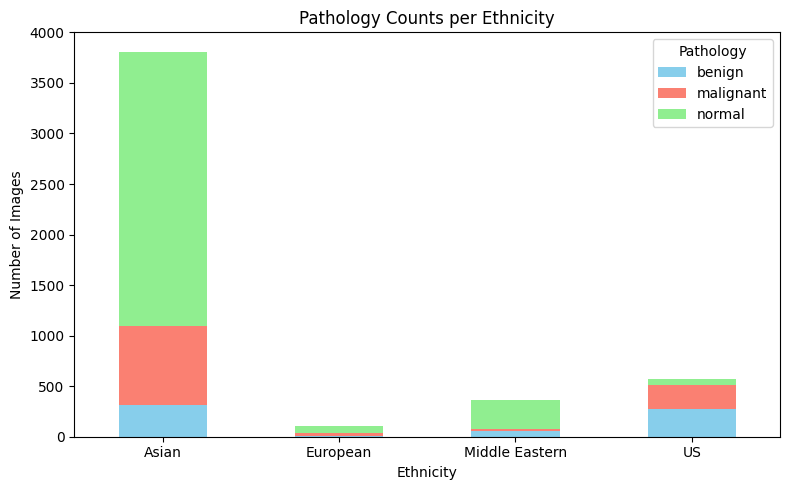

In [6]:
# Plot stacked bar chart
label_counts.plot(kind='bar',
                  stacked=True, 
                  color=['skyblue', 'salmon', 'lightgreen'], 
                  figsize=(8,5))

plt.title("Pathology Counts per Ethnicity")
plt.ylabel("Number of Images")
plt.xlabel("Ethnicity")
plt.xticks(rotation=0)
plt.legend(title="Pathology")
plt.tight_layout()
plt.show()

# Overall Evaluation

## Original (Feature Extract)

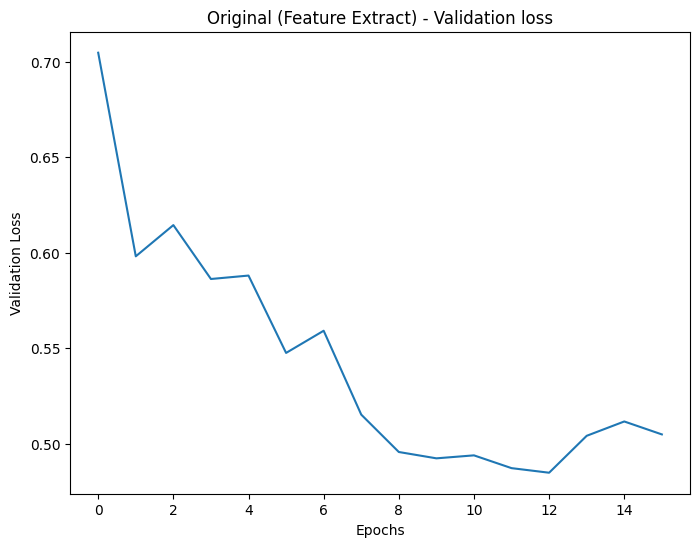

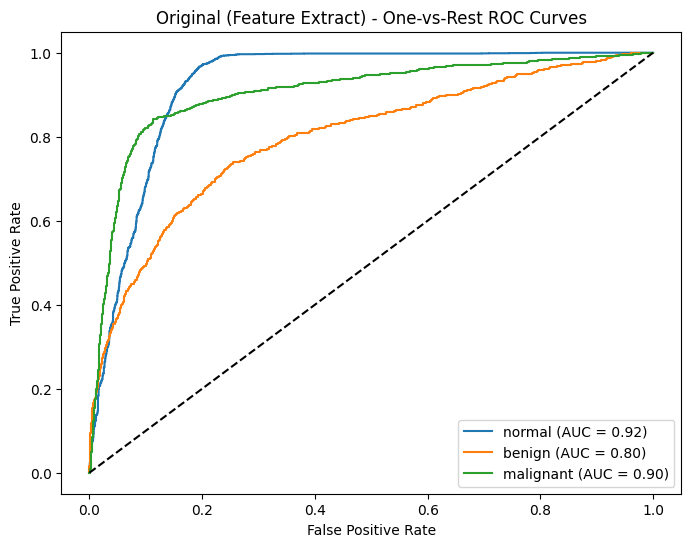

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.871916,0.835998,0.871916,0.743622,0.846988,Asian
1,0.724771,0.666744,0.724771,0.260870,0.647581,European
2,0.805556,0.748158,0.805556,0.000000,0.756310,Middle Eastern
3,0.646957,0.648242,0.646957,0.590717,0.646259,US


## Original (Fine Tune)

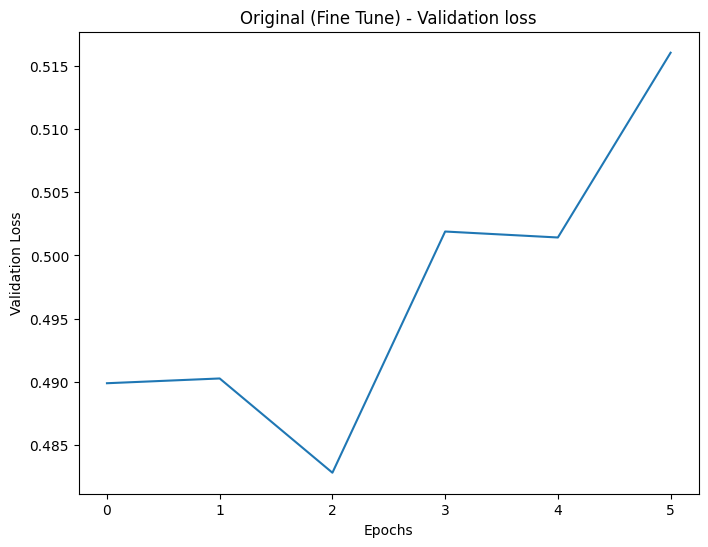

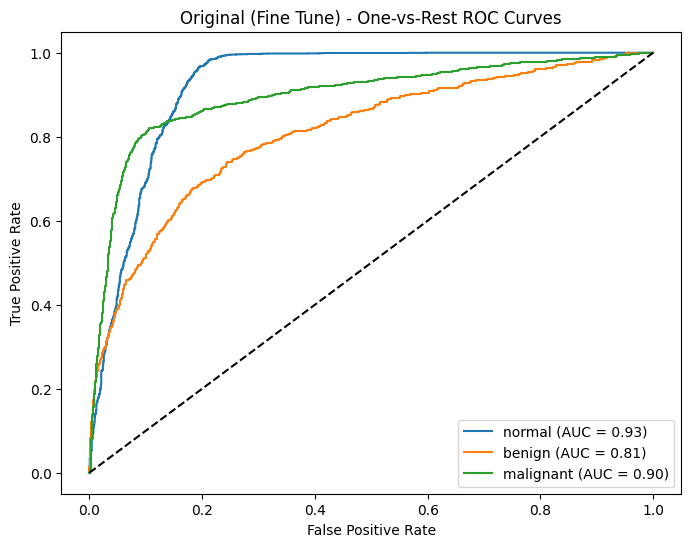

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.875328,0.843509,0.875328,0.764031,0.851210,Asian
1,0.761468,0.697537,0.761468,0.434783,0.700398,European
2,0.805556,0.759353,0.805556,0.000000,0.778384,Middle Eastern
3,0.626087,0.632309,0.626087,0.527426,0.623725,US


## Gap (Feature Extract)

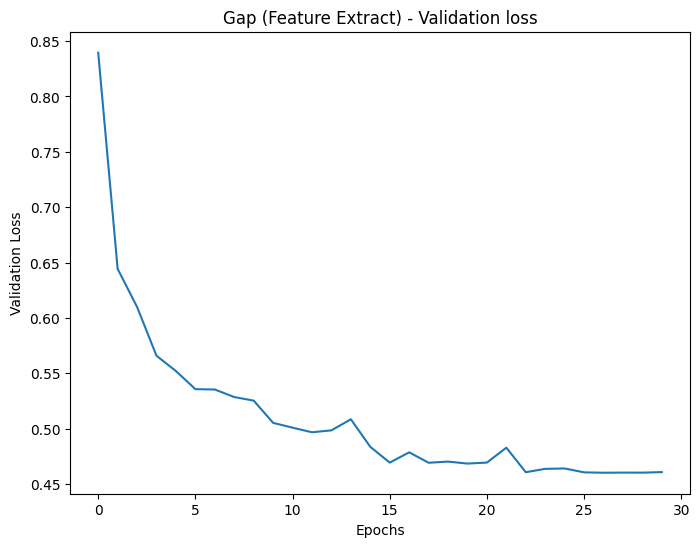

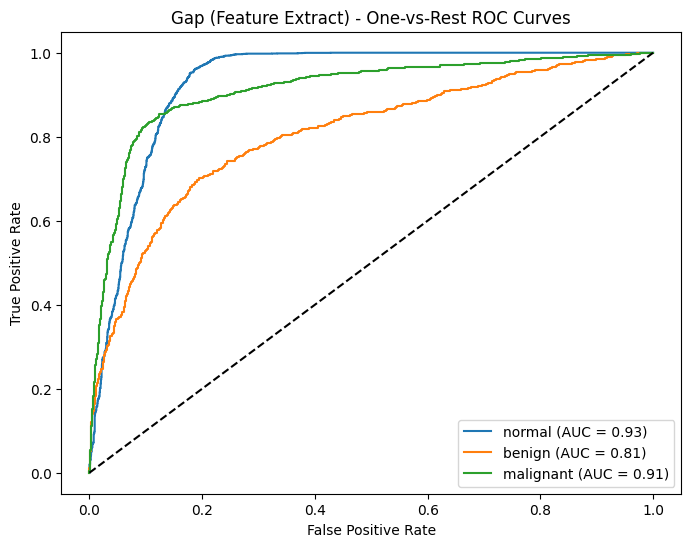

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.879003,0.844772,0.879003,0.794643,0.848574,Asian
1,0.660550,0.633843,0.660550,0.260870,0.627573,European
2,0.813889,0.774222,0.813889,0.062500,0.779723,Middle Eastern
3,0.627826,0.627237,0.627826,0.573840,0.626836,US


## Gap (Fine Tune)

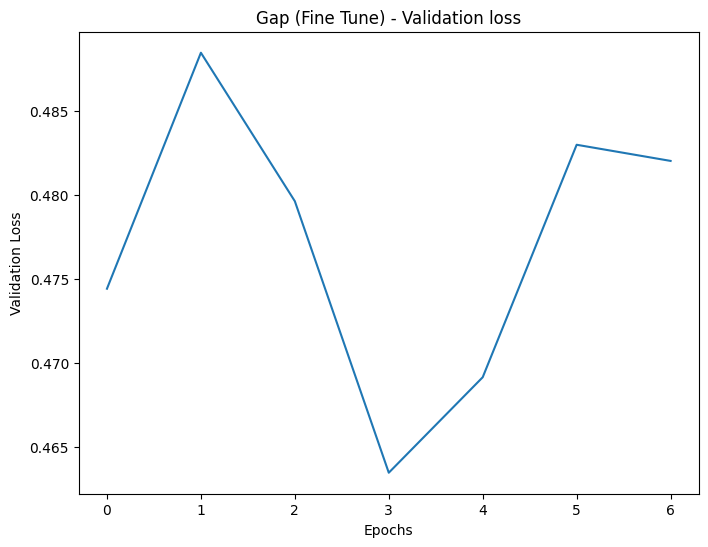

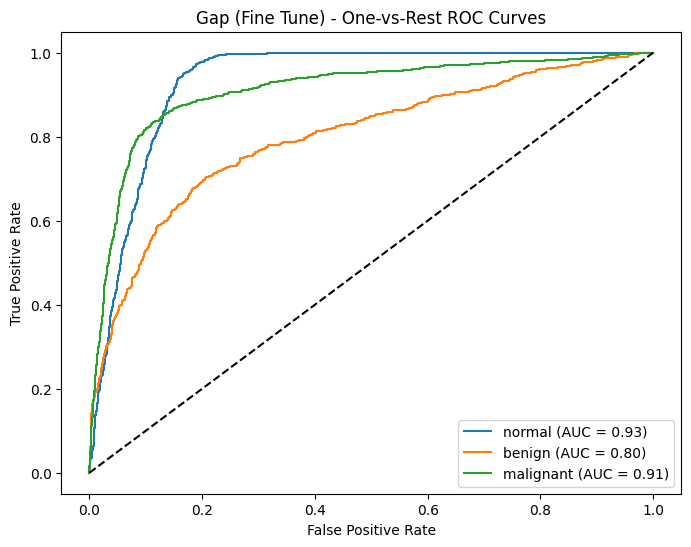

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.866929,0.838129,0.866929,0.724490,0.848447,Asian
1,0.688073,0.651410,0.688073,0.347826,0.651813,European
2,0.816667,0.805983,0.816667,0.062500,0.809155,Middle Eastern
3,0.667826,0.668716,0.667826,0.620253,0.666990,US


## Weighted (Feature Extract)

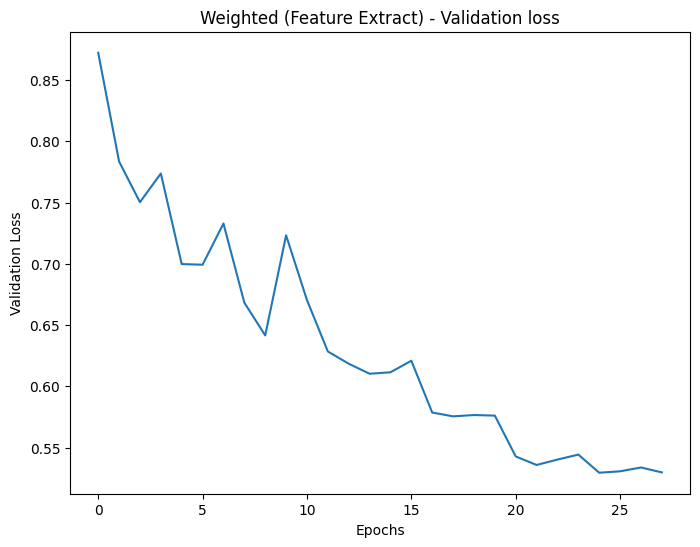

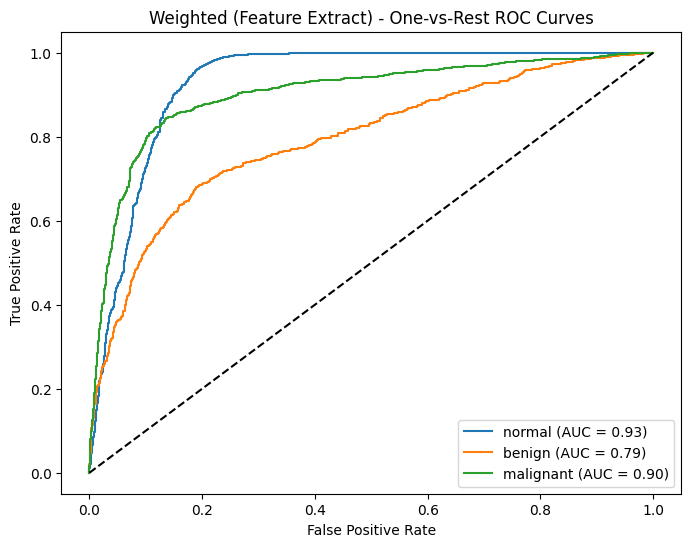

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.862730,0.828319,0.862730,0.747449,0.840748,Asian
1,0.495413,0.555546,0.495413,0.347826,0.520010,European
2,0.730556,0.817879,0.730556,0.187500,0.752158,Middle Eastern
3,0.612174,0.642954,0.612174,0.409283,0.589163,US


## Weighted (Fine Tune)

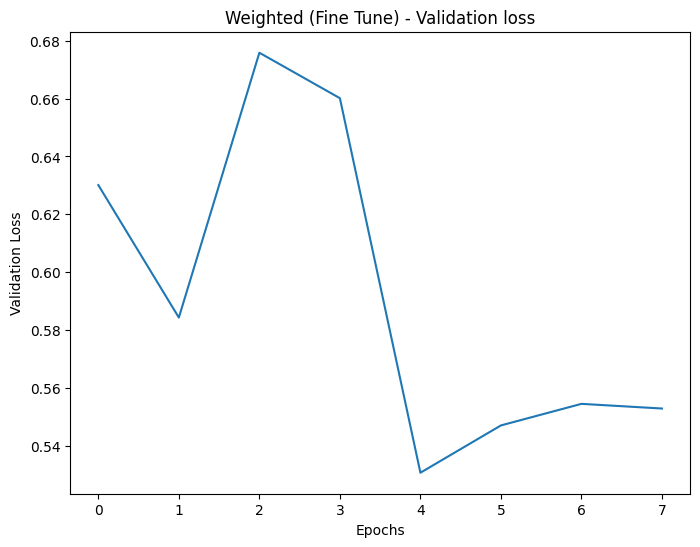

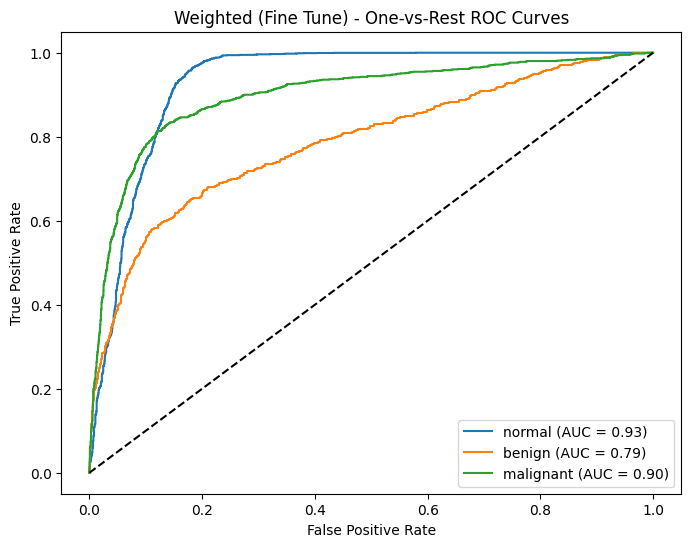

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.848556,0.836233,0.848556,0.674745,0.841040,Asian
1,0.605505,0.633007,0.605505,0.434783,0.616871,European
2,0.786111,0.818482,0.786111,0.125000,0.793428,Middle Eastern
3,0.662609,0.671240,0.662609,0.535865,0.654090,US


## Attention (Feature Extract)

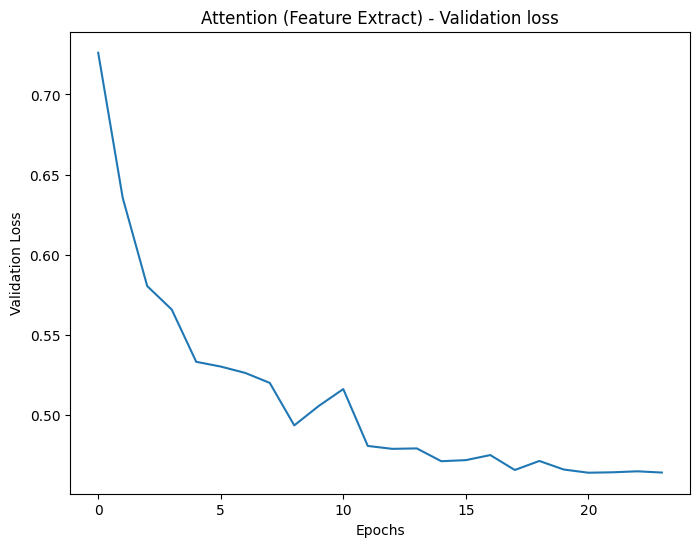

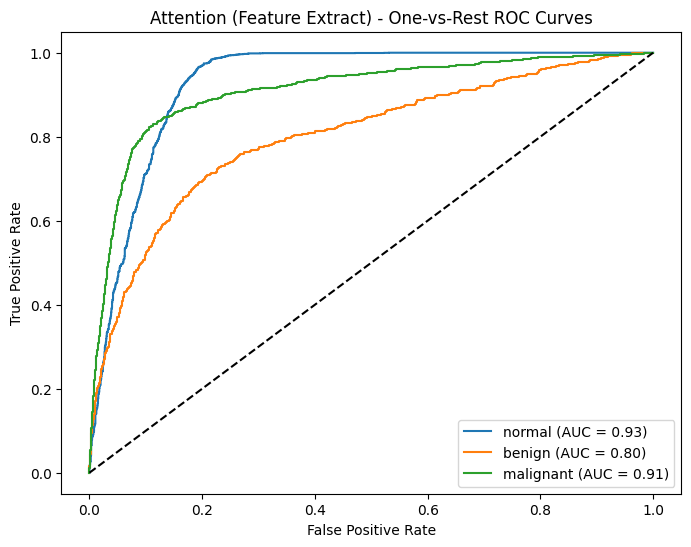

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.875591,0.836737,0.875591,0.790816,0.845238,Asian
1,0.688073,0.661266,0.688073,0.260870,0.645096,European
2,0.811111,0.773940,0.811111,0.062500,0.785494,Middle Eastern
3,0.617391,0.618092,0.617391,0.510549,0.614040,US


## Attention (Fine Tune)

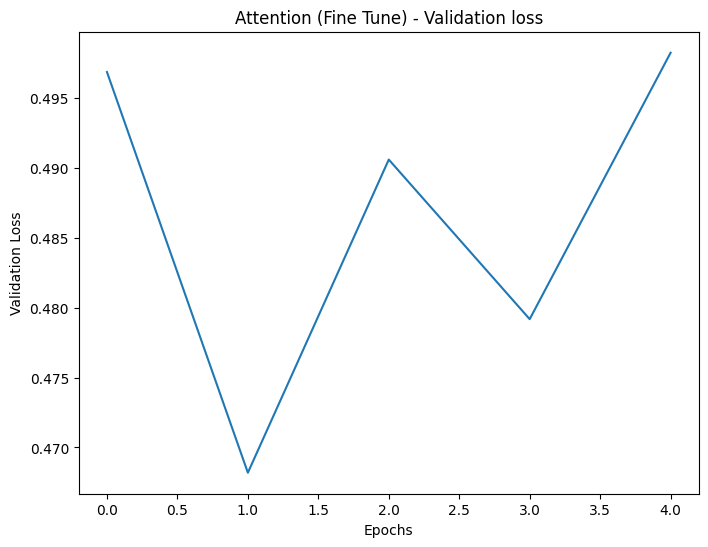

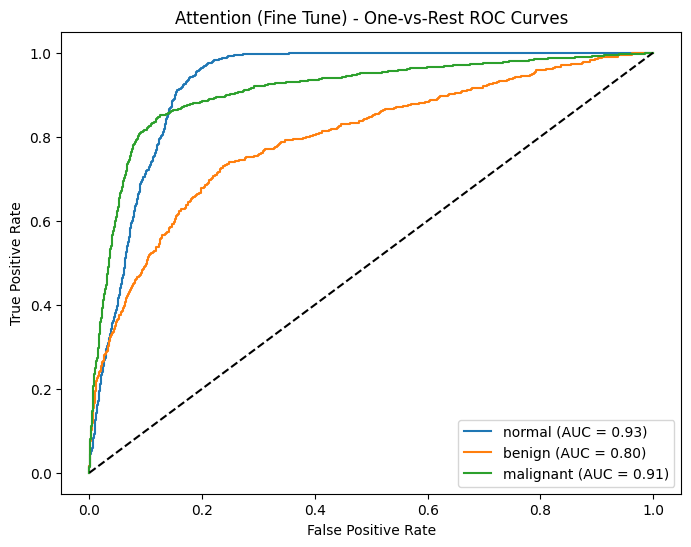

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.870866,0.835508,0.870866,0.747449,0.845704,Asian
1,0.688073,0.617919,0.688073,0.173913,0.609088,European
2,0.797222,0.780899,0.797222,0.062500,0.788581,Middle Eastern
3,0.615652,0.624369,0.615652,0.493671,0.611573,US


## Sample Weighted (Feature Extract)

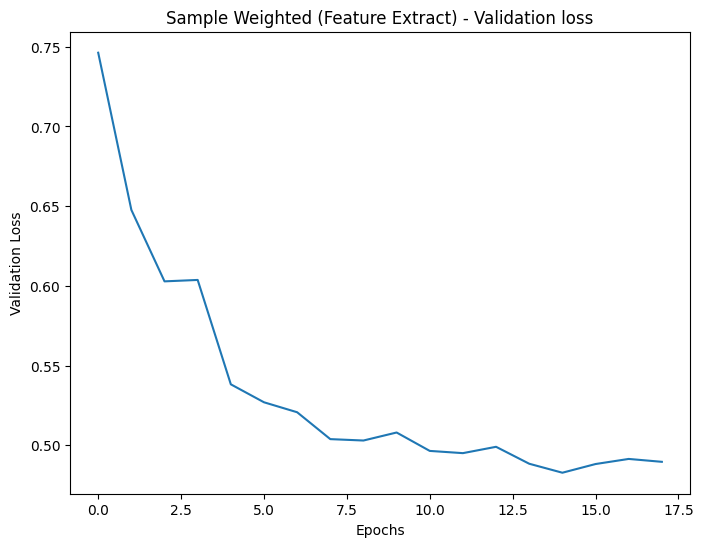

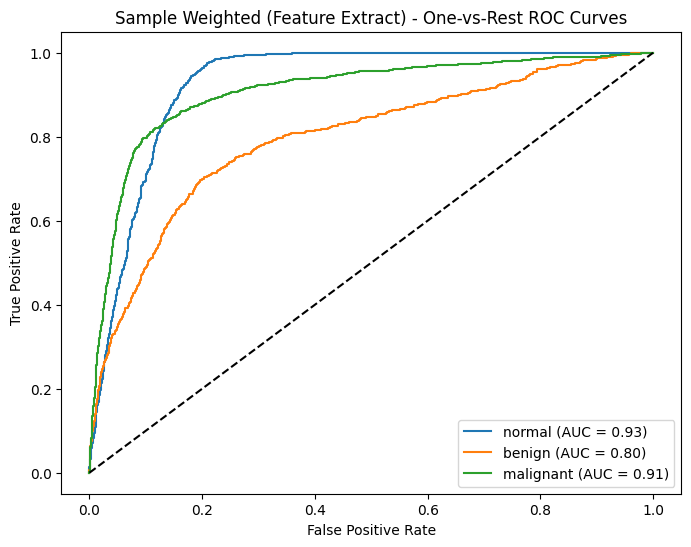

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.860892,0.827259,0.860892,0.693878,0.839345,Asian
1,0.669725,0.624168,0.669725,0.130435,0.586924,European
2,0.802778,0.759208,0.802778,0.000000,0.778936,Middle Eastern
3,0.593043,0.606022,0.593043,0.388186,0.579666,US


## Sample Weighted (Fine Tune)

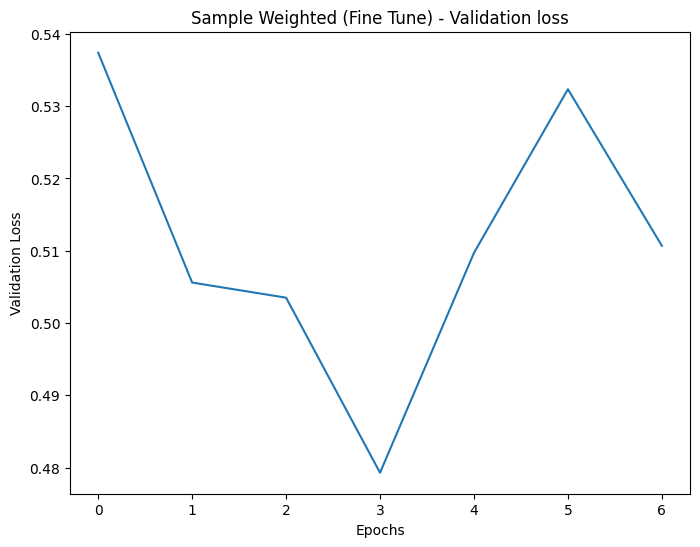

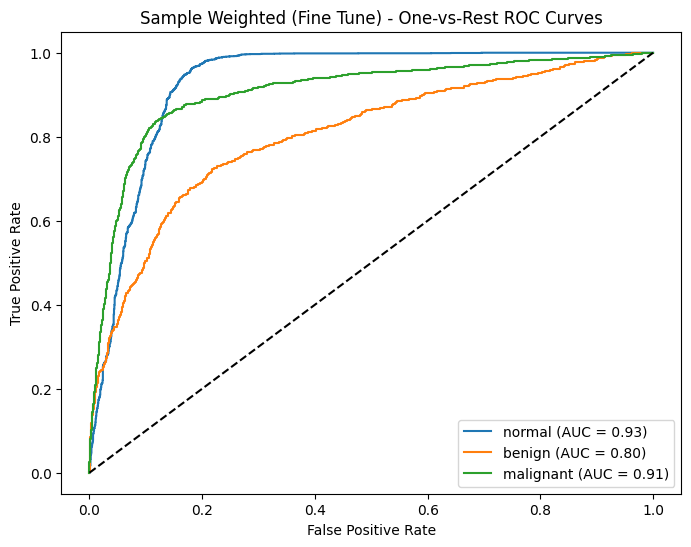

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.856430,0.830958,0.856430,0.656888,0.839621,Asian
1,0.678899,0.630446,0.678899,0.173913,0.612498,European
2,0.847222,0.813081,0.847222,0.000000,0.829643,Middle Eastern
3,0.629565,0.639532,0.629565,0.481013,0.623524,US


In [7]:
overview_table = eval_all_models(models, test_df)

In [8]:
overview_table

,Model,Normal AUC,Benign AUC,Malignant AUC,Macro AUC,Accuracy,Precision,Recall,Malignant Recall,F1,Macro Malignant Recall,Min F1,Std (F1)
0,Original FE,0.924603,0.796950,0.904545,0.875366,0.837042,0.817943,0.837042,0.687736,0.821440,0.398802,0.646259,0.083745
1,Original FT,0.925364,0.809398,0.896871,0.877211,0.838072,0.820709,0.838072,0.692453,0.824850,0.431560,0.623725,0.085029
2,Gap FE,0.929297,0.805586,0.912055,0.882313,0.839514,0.820299,0.839514,0.722642,0.822938,0.422963,0.626836,0.096590
3,Gap FT,0.931188,0.798943,0.910141,0.880090,0.835600,0.820675,0.835600,0.683019,0.825426,0.438767,0.651813,0.085999
4,Weighted FE,0.928744,0.793069,0.902181,0.874665,0.814998,0.810825,0.814998,0.654717,0.812099,0.423014,0.520010,0.127293
5,Weighted FT,0.930720,0.786791,0.898945,0.872152,0.816440,0.817109,0.816440,0.630189,0.815399,0.442598,0.616871,0.093355
6,Attention FE,0.928167,0.800858,0.908745,0.879257,0.836012,0.816973,0.836012,0.705660,0.820991,0.406184,0.614040,0.095900
7,Attention FT,0.925612,0.795344,0.909167,0.876708,0.831067,0.812596,0.831067,0.667925,0.817008,0.369383,0.609088,0.105363
8,Sample Weighted FE,0.925676,0.795905,0.907594,0.876392,0.820560,0.805431,0.820560,0.602830,0.808651,0.303124,0.579666,0.114953
9,Sample Weighted FT,0.929113,0.803967,0.905855,0.879645,0.824887,0.812473,0.824887,0.597170,0.814533,0.327953,0.612498,0.108438


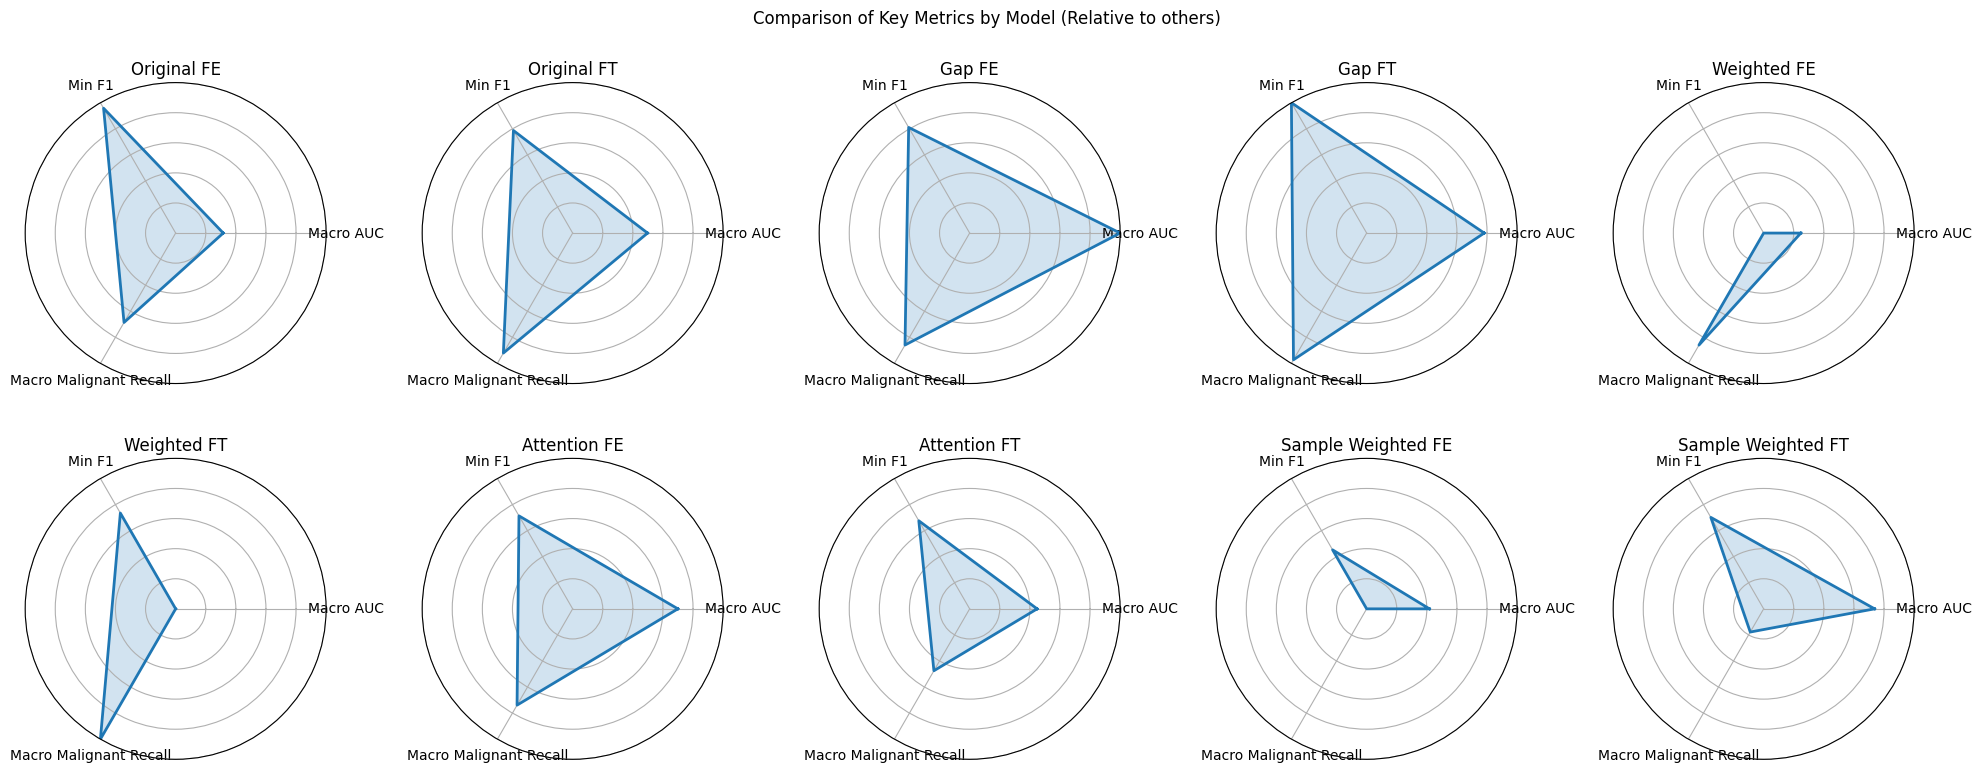

In [9]:
key_metrics = ["Macro AUC", "Min F1", "Macro Malignant Recall"]
areas = create_radar_plots(overview_table,
                           key_metrics,
                           None,
                           5,
                           "Comparison of Key Metrics by Model (Relative to others)")

In [10]:
top_areas = areas.sort_values(by="Radar Area", ascending=False).head(3)
top_models = top_areas.index
top_areas

,Radar Area
Gap FT,1.088438
Gap FE,1.024559
Original FT,0.681947


# Ensemble

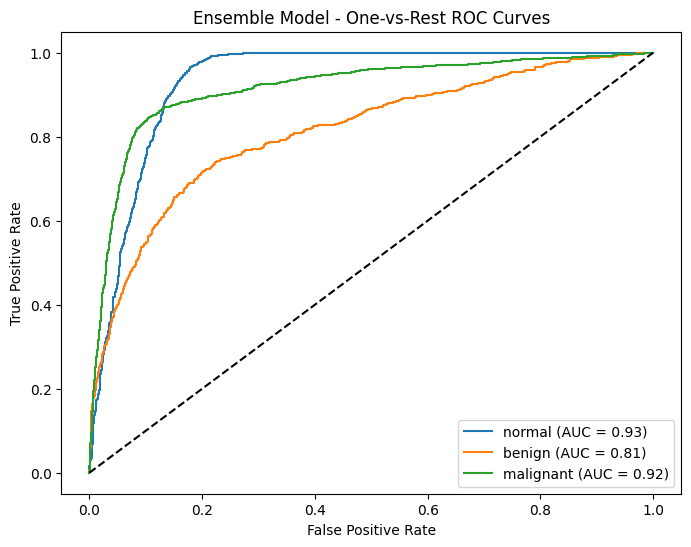

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.876640,0.841475,0.876640,0.779337,0.850197,Asian
1,0.743119,0.728708,0.743119,0.391304,0.696855,European
2,0.825000,0.787484,0.825000,0.062500,0.796323,Middle Eastern
3,0.652174,0.653702,0.652174,0.578059,0.650467,US


In [11]:
# Extract actual models from models dictionary
ensemble_models = [models[model_name]["model"] for model_name in top_models.values]
# Weights = radar area
ensemble_weights = top_areas["Radar Area"].values
# Create ensemble_model
ensemble_model = WeightedEnsemble(ensemble_models, ensemble_weights)
# Evaluate
overview_ensemble = overview_eval(ensemble_model, None, test_df, create_ds_from_df(test_df), "Ensemble Model")

In [12]:
# Prepare dictionary
data_to_save = {"file_paths": ["vgg16_gap_feature_extract", "vgg16_gap_fine_tune", "vgg16_fine_tune"],
                "weights": ensemble_weights.tolist()}

# Save to JSON
with open(os.path.join(MODEL_PATH, "ensemble_metadata.json"), "w") as f:
    json.dump(data_to_save, f)

In [13]:
overview_ensemble

,Normal AUC,Benign AUC,Malignant AUC,Macro AUC,Accuracy,Precision,Recall,Malignant Recall,F1,Macro Malignant Recall,Min F1,Std (F1)
0,0.933167,0.812865,0.915433,0.887155,0.843222,0.82515,0.843222,0.715094,0.82855,0.4528,0.650467,0.07891


# Ensemble Model (Threshold Tuned)

In [14]:
# Predict probabilities on the test dataset
y_probs = ensemble_model.predict(test_ds, verbose=0)
y_true = test_df['label_int'].values

# Get best threshold
best_t = find_threshold_for_best_f1(y_true, y_probs, 2)
with open(os.path.join(MODEL_PATH, "best_threshold.json"), "w") as f:
    json.dump(best_t, f)

In [15]:
# Apply custom threshold
y_pred = predict_with_threshold(y_probs, 2, best_t)

# Evaluate metrics
metrics = pd.DataFrame([compute_metrics(test_df["label_int"].values, y_pred)])
metrics

,Accuracy,Precision,Recall,Malignant Recall,F1
0,0.84796,0.834797,0.84796,0.812264,0.826468


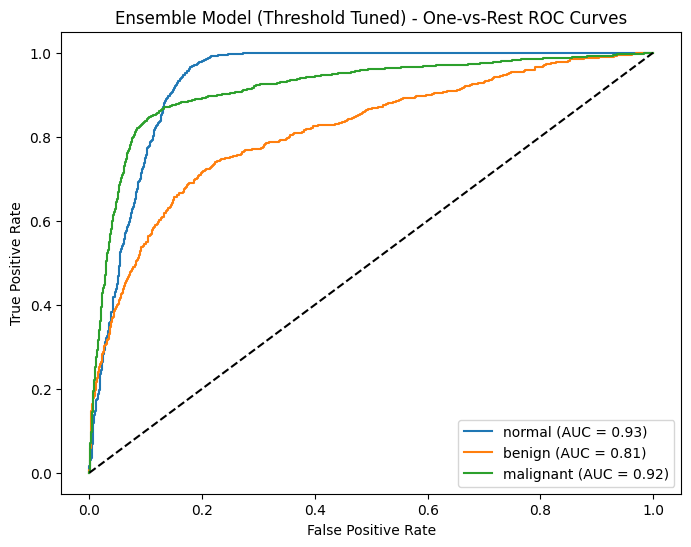

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.882415,0.861772,0.882415,0.852041,0.846758,Asian
1,0.715596,0.677219,0.715596,0.434783,0.677085,European
2,0.825000,0.787484,0.825000,0.062500,0.796323,Middle Eastern
3,0.659130,0.671000,0.659130,0.767932,0.654738,US


In [16]:
overview_ensemble_threshold = overview_eval(ensemble_model, None, test_df, test_ds, "Ensemble Model (Threshold Tuned)", best_t)

In [17]:
overview_ensemble_threshold

,Normal AUC,Benign AUC,Malignant AUC,Macro AUC,Accuracy,Precision,Recall,Malignant Recall,F1,Macro Malignant Recall,Min F1,Std (F1)
0,0.933167,0.812865,0.915433,0.887155,0.84796,0.834797,0.84796,0.812264,0.826468,0.529314,0.654738,0.080222


# Ensemble Model (Target Trained)

In [18]:
tt_model_configs = {
    "GAP FE TT": ("vgg16_gap_fe_targeted_train", "GAP FE Targeted Train"),
    "GAP FT TT": ("vgg16_gap_ft_targeted_train", "GAP FT Targeted Train"),
    "Original FT TT": ("vgg16_ft_targeted_train", "Original FT Targeted Train"),
}

tt_models = {}

for key, (file_name, long_name) in tt_model_configs.items():
    model, history = load_model_and_history(MODEL_PATH, file_name)
    tt_models[key] = {"model": model,
                      "history": history,
                      "long_name": long_name}

## GAP FE Targeted Train

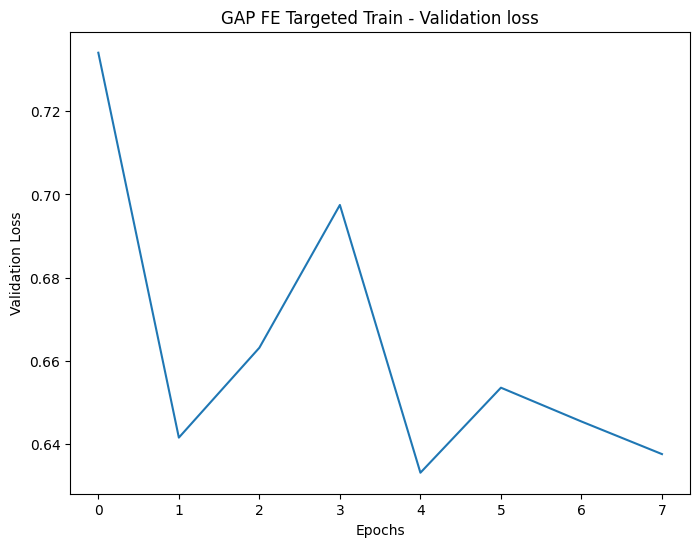

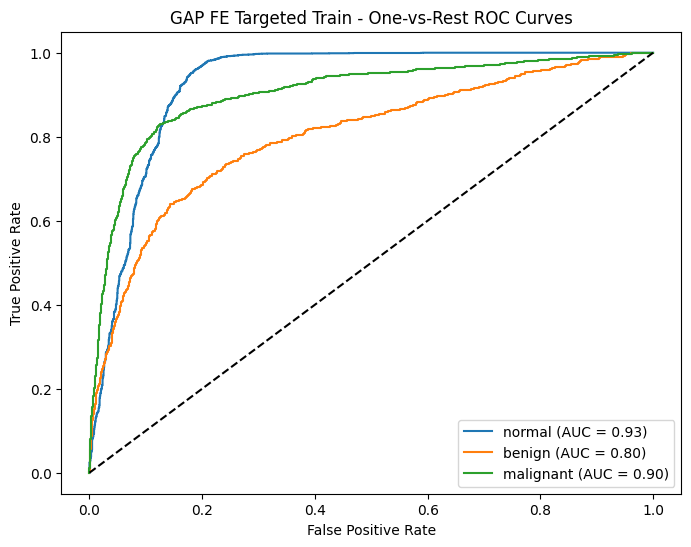

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.872966,0.834880,0.872966,0.757653,0.846303,Asian
1,0.660550,0.608767,0.660550,0.304348,0.621374,European
2,0.827778,0.796708,0.827778,0.062500,0.806505,Middle Eastern
3,0.586087,0.586774,0.586087,0.400844,0.575075,US


## GAP FT Targeted Train

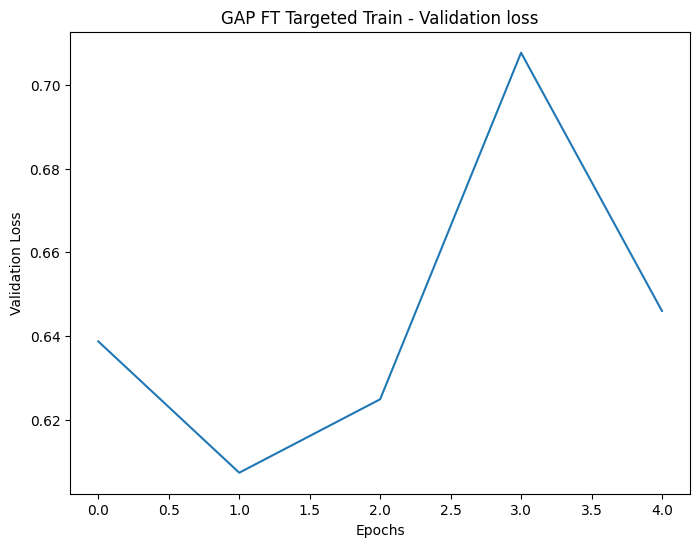

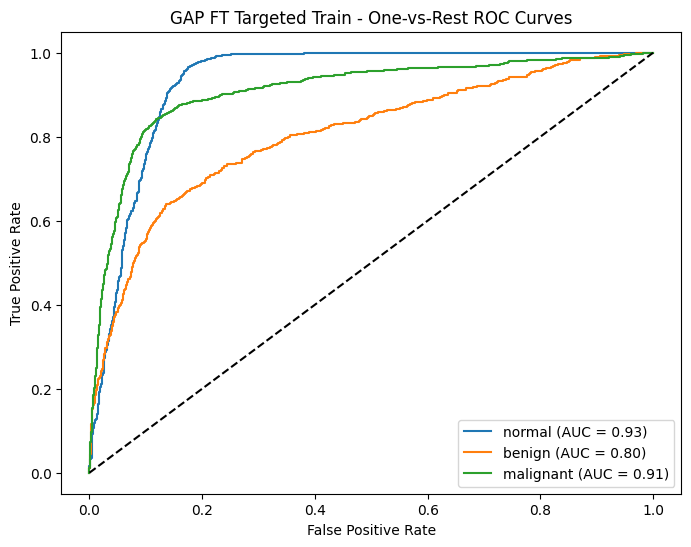

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.867717,0.836284,0.867717,0.734694,0.846926,Asian
1,0.660550,0.597741,0.660550,0.391304,0.622987,European
2,0.850000,0.825720,0.850000,0.125000,0.831860,Middle Eastern
3,0.653913,0.653943,0.653913,0.637131,0.653908,US


## Original FT Targeted Train

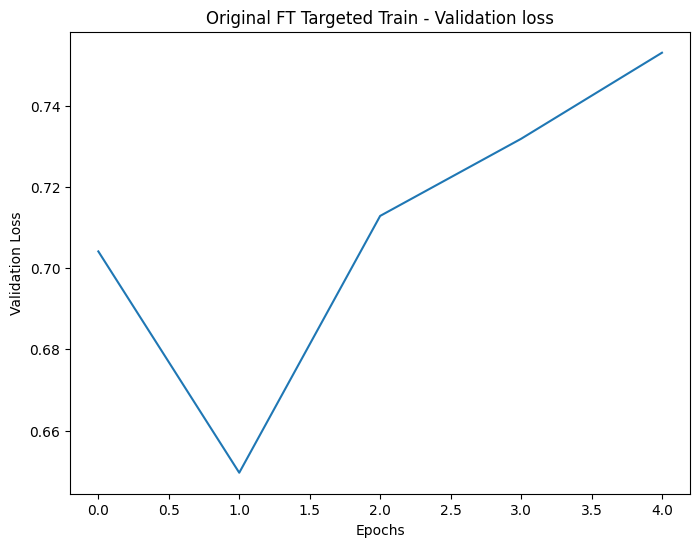

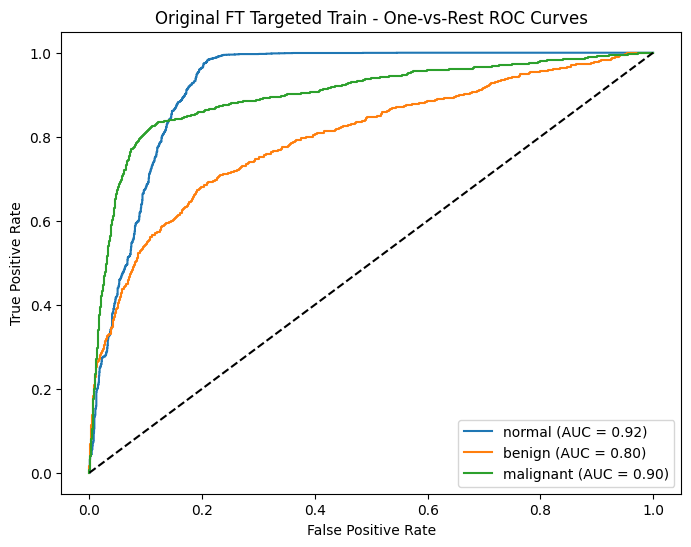

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.875066,0.834543,0.875066,0.801020,0.845724,Asian
1,0.697248,0.623623,0.697248,0.478261,0.655324,European
2,0.825000,0.788514,0.825000,0.062500,0.796539,Middle Eastern
3,0.629565,0.632441,0.629565,0.565401,0.628627,US


In [19]:
tt_table = eval_all_models(tt_models, test_df)
overview_tt_table = pd.concat([overview_table, tt_table], ignore_index=True)

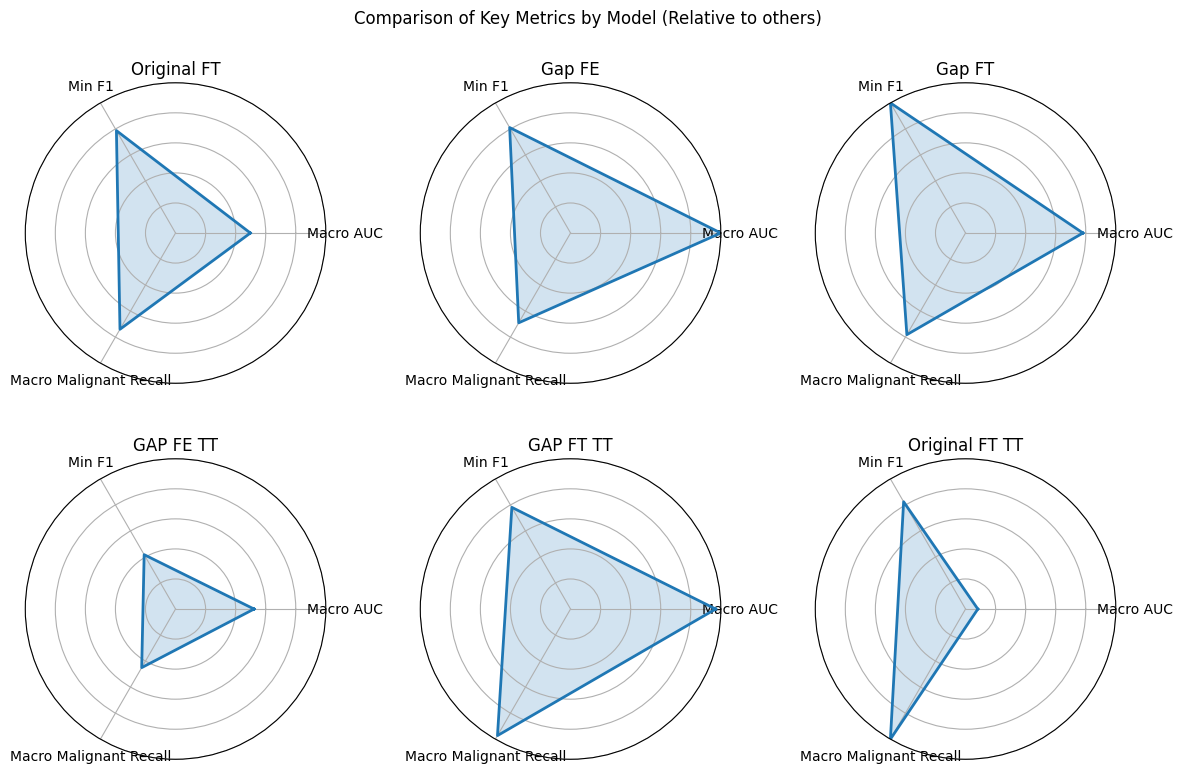

,Radar Area
GAP FT TT,1.062577
Gap FT,0.940730
Gap FE,0.891921


In [20]:
areas_tt = create_radar_plots(overview_tt_table,
                           key_metrics,
                           ["Gap FE", "Gap FT", "Original FT", "GAP FE TT", "GAP FT TT", "Original FT TT"],
                           3,
                           "Comparison of Key Metrics by Model (Relative to others)")

top_areas_new = areas_tt.sort_values(by="Radar Area", ascending=False).head(3)
top_models_new = top_areas_new.index
top_areas_new

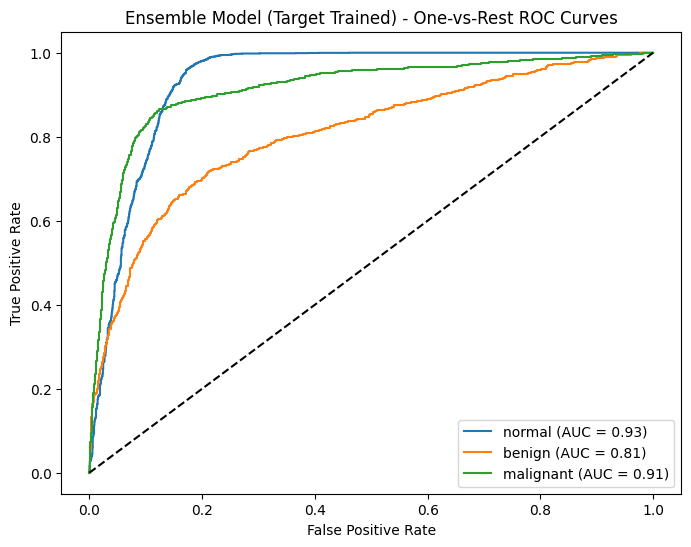

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.872703,0.838729,0.872703,0.758929,0.849016,Asian
1,0.688073,0.653099,0.688073,0.347826,0.657165,European
2,0.850000,0.824960,0.850000,0.125000,0.830088,Middle Eastern
3,0.653913,0.654076,0.653913,0.594937,0.652907,US


In [21]:
# Combine dictionaries
models = models | tt_models
# Extract actual models from models dictionary
ensemble_models_tt = [models[model_name]["model"] for model_name in top_models_new.values]
# Weights = radar area
ensemble_weights_tt = top_areas_new["Radar Area"].values
# Create ensemble_model
ensemble_model_tt = WeightedEnsemble(ensemble_models_tt, ensemble_weights_tt)
# Evaluate
overview_ensemble_tt = overview_eval(ensemble_model_tt, None, test_df, create_ds_from_df(test_df), "Ensemble Model (Target Trained)")

# Ensemble Model (Target Trained & Threshold Tuned)

In [22]:
# Predict probabilities on the test dataset
y_probs_tt = ensemble_model_tt.predict(test_ds, verbose=0)

# Get best threshold
best_t_tt = find_threshold_for_best_f1(y_true, y_probs_tt, 2)
with open(os.path.join(MODEL_PATH, "best_threshold_tt.json"), "w") as f:
    json.dump(best_t, f)

# Apply custom threshold
y_pred_tt = predict_with_threshold(y_probs_tt, 2, best_t_tt)

# Evaluate metrics
metrics = pd.DataFrame([compute_metrics(test_df["label_int"].values, y_pred_tt)])
metrics

,Accuracy,Precision,Recall,Malignant Recall,F1
0,0.846106,0.831729,0.846106,0.795283,0.82723


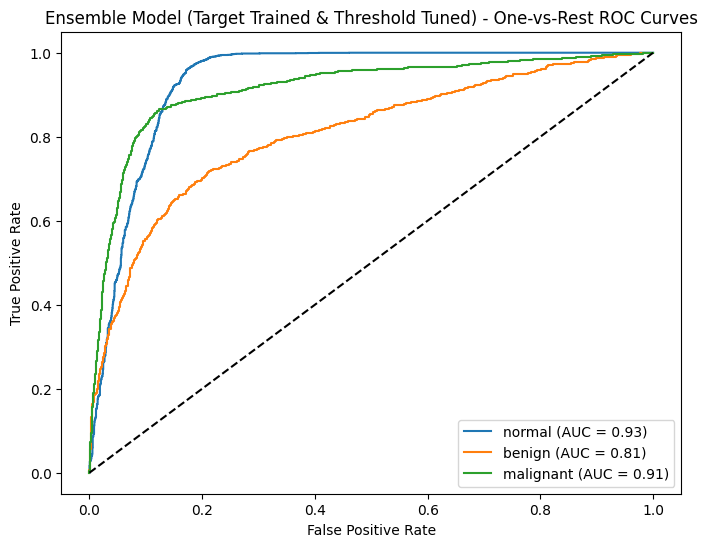

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.879790,0.840772,0.879790,0.834184,0.846674,Asian
1,0.678899,0.642980,0.678899,0.347826,0.649725,European
2,0.847222,0.822538,0.847222,0.125000,0.828309,Middle Eastern
3,0.653913,0.663697,0.653913,0.755274,0.651206,US


,Normal AUC,Benign AUC,Malignant AUC,Macro AUC,Accuracy,Precision,Recall,Malignant Recall,F1,Macro Malignant Recall,Min F1,Std (F1)
0,0.933167,0.812865,0.915433,0.887155,0.84796,0.834797,0.84796,0.812264,0.826468,0.529314,0.654738,0.080222


In [23]:
overview_ensemble_tt_threshold = overview_eval(ensemble_model_tt, None, test_df, test_ds, "Ensemble Model (Target Trained & Threshold Tuned)", best_t_tt)
overview_ensemble_threshold

,Accuracy,Precision,Recall,Malignant Recall,F1
0,0.84178,0.824757,0.84178,0.771698,0.825139


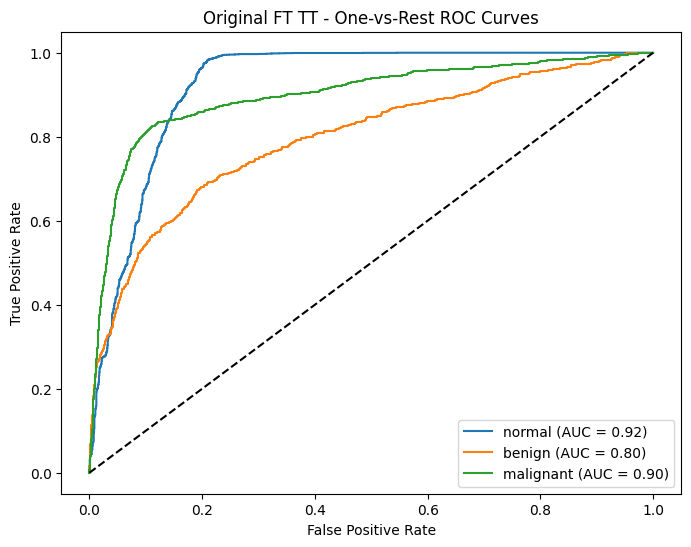

,Accuracy,Precision,Recall,Malignant Recall,F1,ethnicity_grouped
0,0.876903,0.832864,0.876903,0.834184,0.843502,Asian
1,0.706422,0.627800,0.706422,0.521739,0.663275,European
2,0.825000,0.788514,0.825000,0.062500,0.796539,Middle Eastern
3,0.645217,0.646352,0.645217,0.637131,0.645515,US


In [24]:
# Predict probabilities
y_probs_original_tt = models["Original FT TT"]["model"].predict(test_ds, verbose=0)

# Find best threshold
best_t_original_tt = find_threshold_for_best_f1(y_true, y_probs_original_tt, 2)

# Apply threshold
y_pred_original_tt = predict_with_threshold(y_probs_original_tt, 2, best_t_original_tt)

# Evaluate metrics
metrics_1 = pd.DataFrame([
    compute_metrics(test_df["label_int"].values, y_pred_original_tt)
])
display(metrics_1)

# Run full evaluation
overview_original_tt_tuned = overview_eval(models["Original FT TT"]["model"], None, test_df, test_ds, "Original FT TT", threshold=best_t_original_tt)

# Model Summaries

In [25]:
# Renaming for clarity
overview_original_tt_tuned["Model"] = "Original FT TT (Threshold Tuned)"
overview_ensemble["Model"] = "Ensemble"
overview_ensemble_threshold["Model"] = "Ensemble (Threshold Tuned)"
overview_ensemble_tt["Model"] = "Ensemble (Target Trained)"
overview_ensemble_tt_threshold["Model"] = "Ensemble (Target Trained & Threshold Tuned)"
master_table = pd.concat([overview_tt_table,
                          overview_original_tt_tuned,
                          overview_ensemble,
                          overview_ensemble_threshold,
                          overview_ensemble_tt,
                          overview_ensemble_tt_threshold],
                         ignore_index=True).drop_duplicates()
master_table.round(3)

,Model,Normal AUC,Benign AUC,Malignant AUC,Macro AUC,Accuracy,Precision,Recall,Malignant Recall,F1,Macro Malignant Recall,Min F1,Std (F1)
0,Original FE,0.925,0.797,0.905,0.875,0.837,0.818,0.837,0.688,0.821,0.399,0.646,0.084
1,Original FT,0.925,0.809,0.897,0.877,0.838,0.821,0.838,0.692,0.825,0.432,0.624,0.085
2,Gap FE,0.929,0.806,0.912,0.882,0.840,0.820,0.840,0.723,0.823,0.423,0.627,0.097
3,Gap FT,0.931,0.799,0.910,0.880,0.836,0.821,0.836,0.683,0.825,0.439,0.652,0.086
4,Weighted FE,0.929,0.793,0.902,0.875,0.815,0.811,0.815,0.655,0.812,0.423,0.520,0.127
5,Weighted FT,0.931,0.787,0.899,0.872,0.816,0.817,0.816,0.630,0.815,0.443,0.617,0.093
6,Attention FE,0.928,0.801,0.909,0.879,0.836,0.817,0.836,0.706,0.821,0.406,0.614,0.096
7,Attention FT,0.926,0.795,0.909,0.877,0.831,0.813,0.831,0.668,0.817,0.369,0.609,0.105
8,Sample Weighted FE,0.926,0.796,0.908,0.876,0.821,0.805,0.821,0.603,0.809,0.303,0.580,0.115
9,Sample Weighted FT,0.929,0.804,0.906,0.880,0.825,0.812,0.825,0.597,0.815,0.328,0.612,0.108


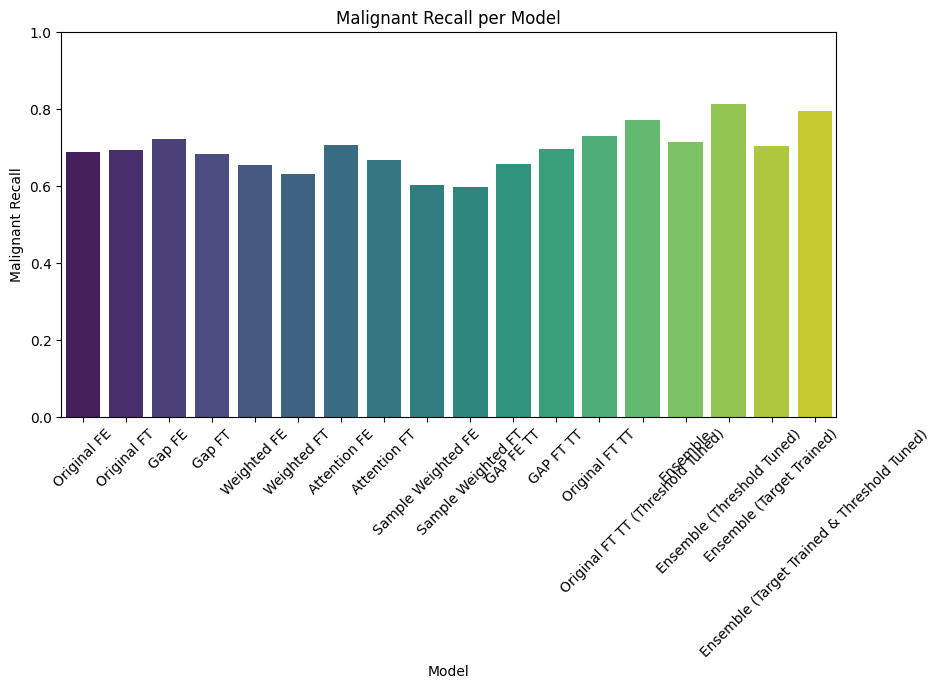

In [26]:
create_box_plot(master_table, "Malignant Recall", "viridis")

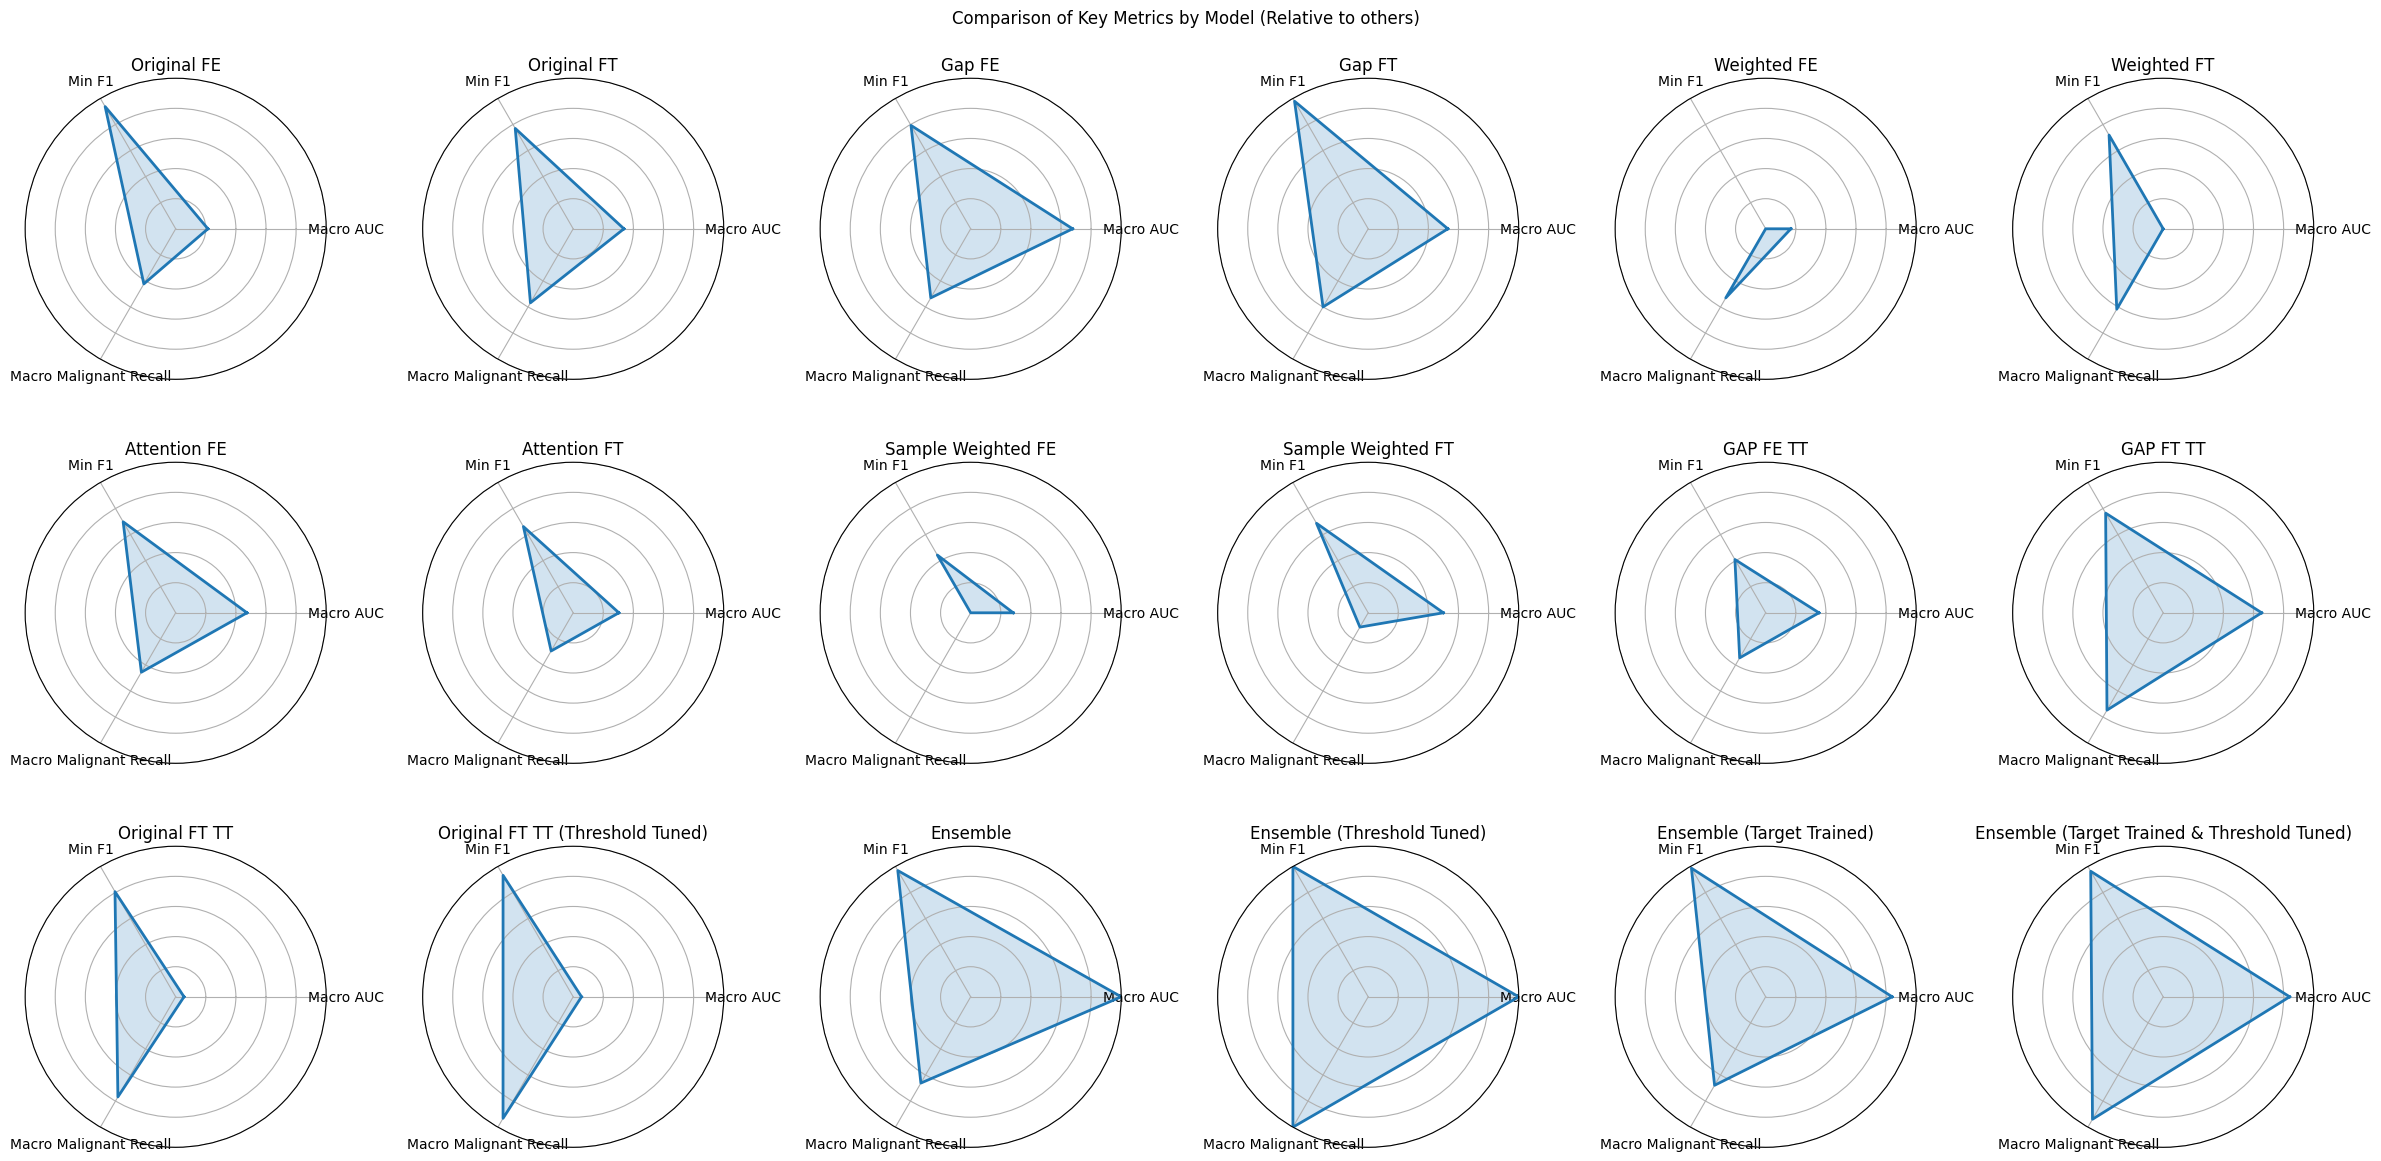

In [27]:
areas = create_radar_plots(master_table,
                           key_metrics,
                           None,
                           6,
                           "Comparison of Key Metrics by Model (Relative to others)")

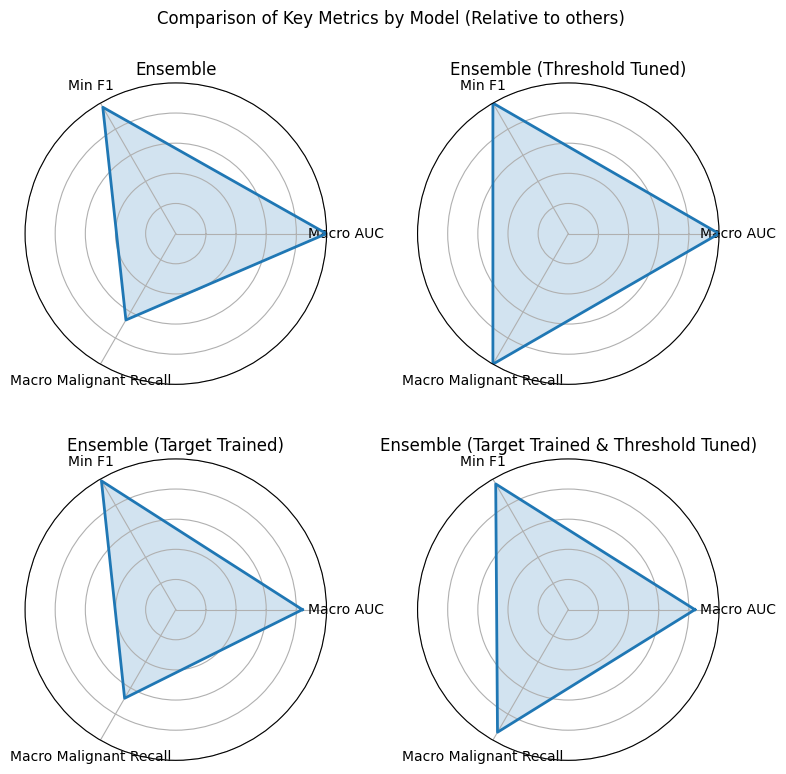

In [28]:
areas = create_radar_plots(master_table,
                           key_metrics,
                           ["Ensemble", "Ensemble (Threshold Tuned)", "Ensemble (Target Trained)", "Ensemble (Target Trained & Threshold Tuned)"],
                           2,
                           "Comparison of Key Metrics by Model (Relative to others)")

In [29]:
top_model = areas.sort_values(by="Radar Area", ascending=False).head(1).index
top_model

Index(['Ensemble (Threshold Tuned)'], dtype='object')

In [30]:
mean_f1, low_f1, high_f1 = bootstrap_ci(y_true, y_probs, best_t, metric="f1")
mean_mrec, low_mrec, high_mrec = bootstrap_ci(y_true, y_probs, best_t, metric="malignant_recall")

results_df = pd.DataFrame({"Metric": ["Macro F1", "Malignant Recall"],
                "Mean": [mean_f1, mean_mrec],
                "CI Lower": [low_f1, low_mrec],
                "CI Upper": [high_f1, high_mrec]})
results_df

,Metric,Mean,CI Lower,CI Upper
0,Macro F1,0.698295,0.682092,0.714401
1,Malignant Recall,0.811550,0.786686,0.834916


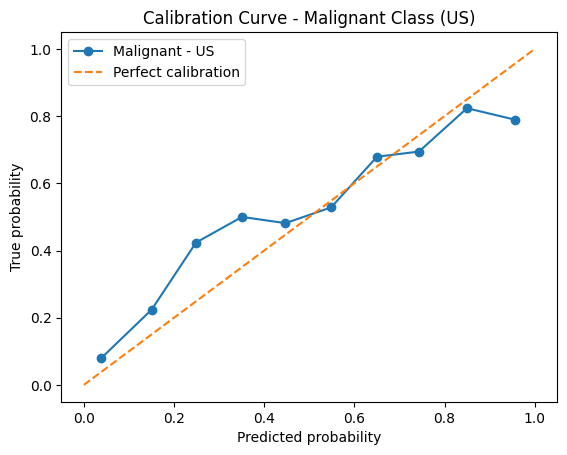

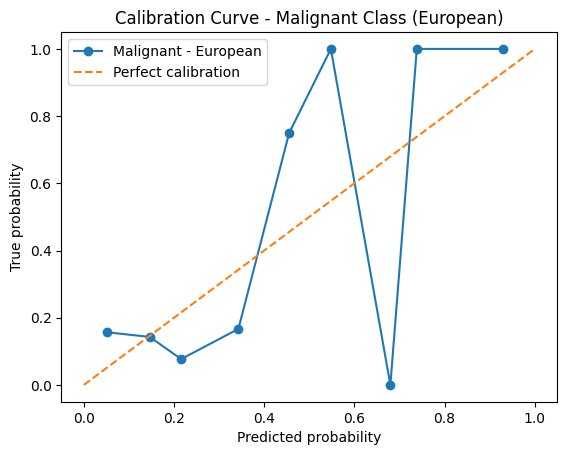

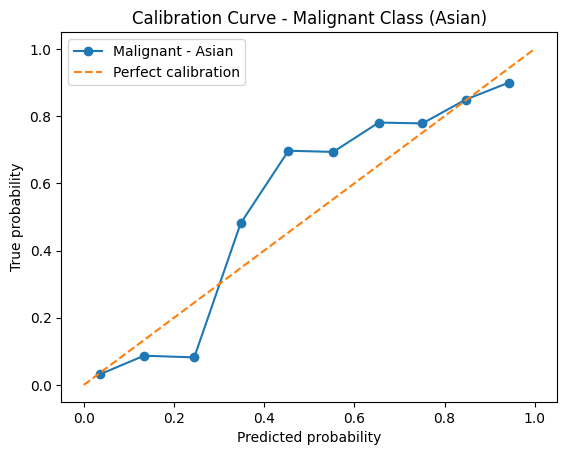

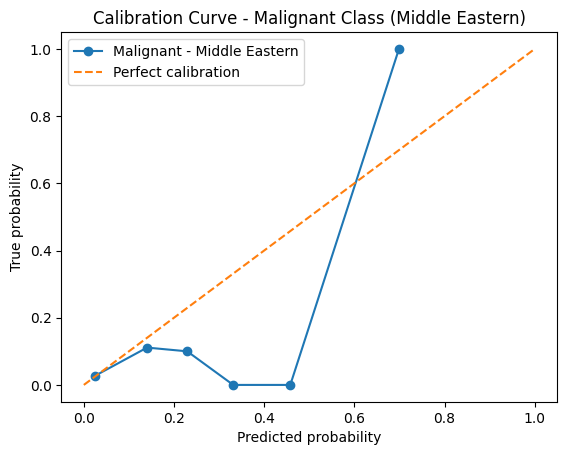

,ethnicity_grouped,Brier Score,CI Lower,CI Upper,n_samples
0,US,0.188435,0.170039,0.206527,575
1,European,0.136889,0.091125,0.190378,109
2,Asian,0.068389,0.062358,0.074282,3810
3,Middle Eastern,0.041390,0.024868,0.060478,360


In [31]:
# Convert results to DataFrame
brier_eth_df = plot_fairness_calibration(test_df, y_probs)
brier_eth_df

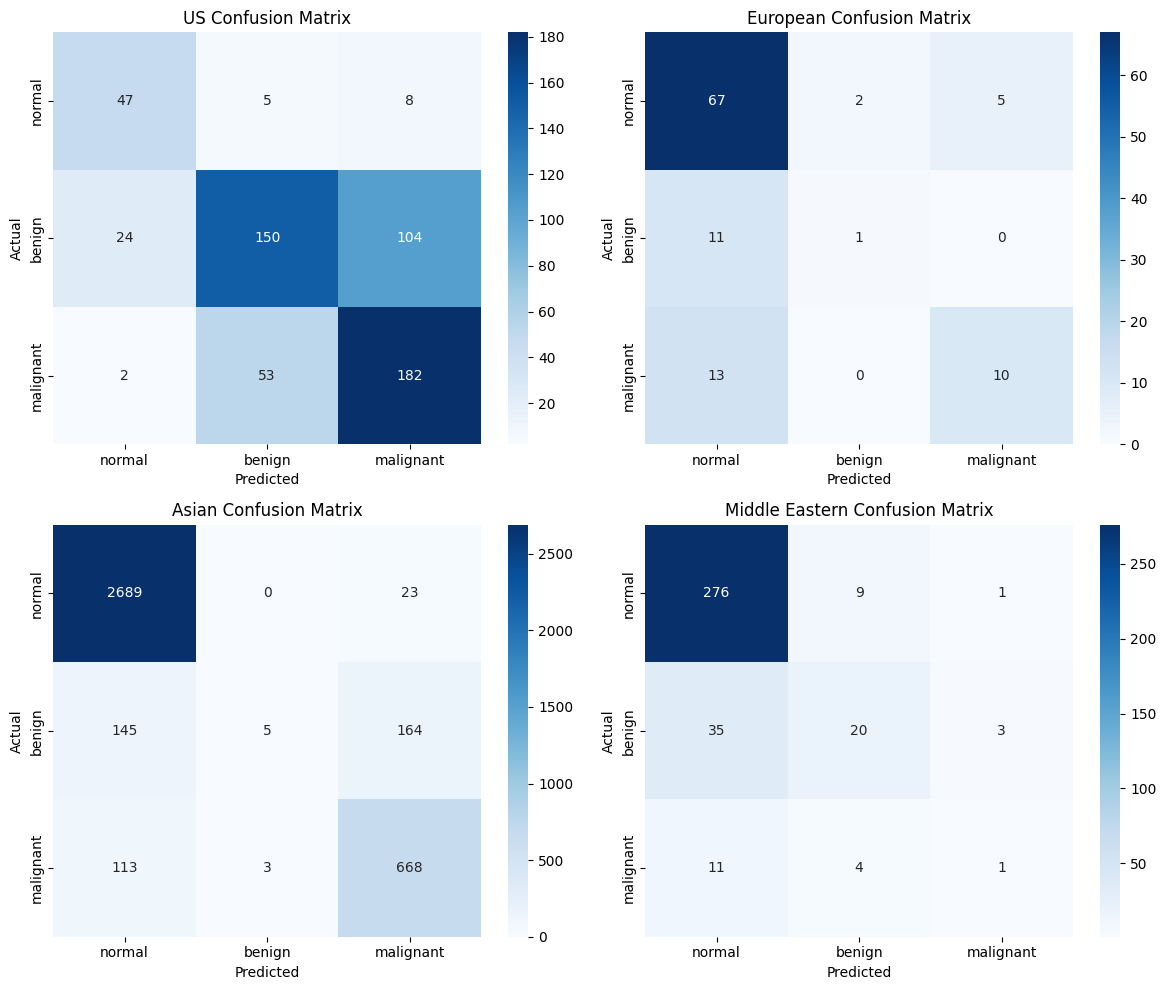

In [73]:
plot_confusion_matrices_by_group(test_df, y_true, y_pred, "ethnicity_grouped", 2, ["normal", "benign", "malignant"])